# Autocorrelación

La autocorrelación es una herramienta estadística y de procesamiento de señales que mide el grado de similitud entre una señal $x(t)$ y una versión desplazada en el tiempo de sí misma, $x(t - \tau)$, en función del retardo o lag $\tau$



- $cov(x,x)=var(x)$
- $cov(c,x)=0$
- $cov(x,y)=cov(y,x)$
- $cov(ax,y)=a\quad  cov(x,y)$
- $cov(x+c,y)=cov(x,y)$

Si x,y son independientes, entonces:

$Cov(x,y)=E[XY]-E[X]E[Y]$

es espurio

In [ ]:
#@title Covarianza de una constante
import numpy as np
import matplotlib.pyplot as plt
seed = np.random.seed(1956)
x = np.random.normal(0,1,10)
y= np.full_like(x,7)
print(np.var(x))
print("-------")
print(np.cov(x,y,bias=False))

0.9306950603803609
-------
[[1.03410562 0.        ]
 [0.         0.        ]]


In [ ]:
#@title Indice de Variables Independientes

n=10000
x=np.random.normal(0,1,n)
y=np.random.normal(0,1,n)
print(np.var(x))
print(np.cov(x,y,bias=False))

0.9917451741893919
[[ 0.99184436 -0.01677249]
 [-0.01677249  1.01335347]]


### Coeficiente de Correlación de Pearson y Covarianza

#### 1. Definiciones Matemáticas

* **Covarianza Poblacional:**
  $$\operatorname{Cov}(X,Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])] = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

* **Covarianza Muestral (Insesgada, `ddof=1`):**
  $$s_{xy} = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

* **Coeficiente de Correlación Poblacional ($\rho$):**
  $$\rho_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{\mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]}{\sqrt{\mathbb{E}[X^2] - (\mathbb{E}[X])^2} \sqrt{\mathbb{E}[Y^2] - (\mathbb{E}[Y])^2}}$$

* **Coeficiente de Correlación Muestral ($r_{xy}$):**
  $$r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$

---

#### 2. Propiedades Fundamentales

1. **Acotamiento (Desigualdad de Cauchy-Schwarz):**
   $$-1 \le r(X,Y) \le 1$$
   * $\vert{}r\vert{} = 1$: Existe una relación lineal determinista perfecta.
   * $r = 0$: Ausencia total de asociación de tipo lineal.

2. **Autocorrelación Unitaria:**
   $$r(X,X) = 1 \quad \text{si } \operatorname{Var}(X) > 0$$

3. **Simetría Conmutativa:**
   $$r(X,Y) = r(Y,X)$$

4. **Invarianza ante Transformaciones de Escala (Cambio de Unidad):**
   $$r(aX, bY) = \operatorname{signo}(a \cdot b) \cdot r(X,Y) \quad \forall a, b \neq 0$$
   * Para el caso particular $b = 1$:
   
     $$r(aX, Y) = \frac{a}{\vert{}a\vert{}} r(X,Y) = \operatorname{signo}(a) \cdot r(X,Y)$$

5. **Invarianza ante Traslaciones (Cambio de Origen):**
   $$r(X + c, Y + d) = r(X,Y) \quad \forall c, d \in \mathbb{R}$$

6. **Relación con la Independencia Estocástica:**
   $$X, Y \text{ independientes} \implies \mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y] \implies \operatorname{Cov}(X,Y) = 0 \implies r(X,Y) = 0$$
   *(Nota: El recíproco no es necesariamente cierto; $r = 0$ no implica independencia si existen relaciones no lineales).*

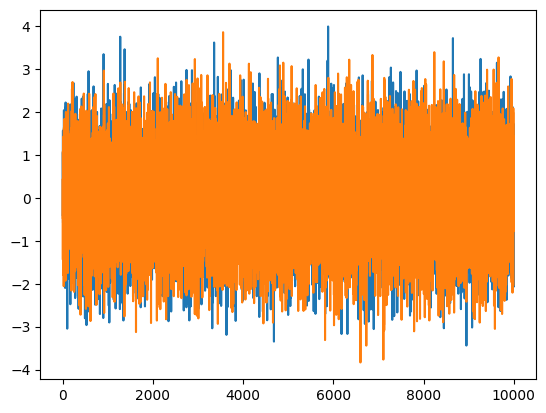

In [ ]:
plt.plot(x)
plt.plot(y)

## Vector de Tiempo y Señales Sinusoidales
En la vida real no existen mediciones continuas, por eso existe la frecuencia de muestreo **(registro)**, hace la diferencia en reconstruir la señal y crear una diferente

### Señal sinusoidal
una señal sinusoidal es una señal que depende del tiempo
$$s_1(t)=Asin(t)$$

- *t* : fase
- *A* : amplitud
- *Periodo* : intervalo de tiempo en el que la señal se repite **(ciclo)** se mide sobre tiempo
- *Frecuencia* : es el inverso del periodo, cuantos ciclos hace por onstante de tiempo
- max($s_1$) = A
- min($s_1$) = -A

#### Fase
Para meter la frecuencia que yo quiero, *ejemplo* : 2
$$s_1(t)=Asin(2\pi f t+\phi_0)$$

- $\phi_0$ fase inicial

> nota: nos estamos moviendo en el tiempo


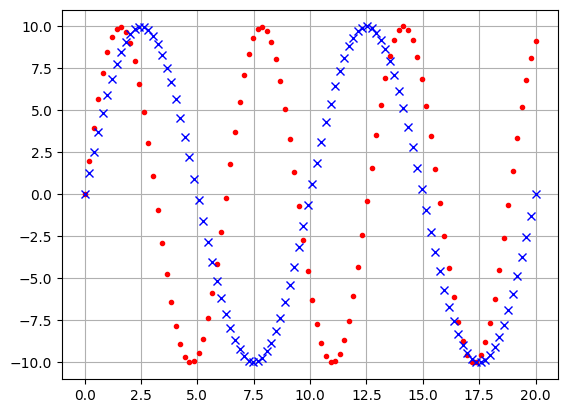

In [ ]:
fr=5 #puntos que se registran en un segundo
fin=20
vTiempo=np.linspace(0,fin,fr*fin)

s_1=10*np.sin(vTiempo)
manipualte=np.pi*2 #Indispensable para manipular la frecuencia de la onda
frecuencia=1/10
s_2=10*np.sin(manipualte*frecuencia*vTiempo)
plt.plot(vTiempo,s_1,".r")
plt.plot(vTiempo,s_2,"xb")
plt.grid(True)


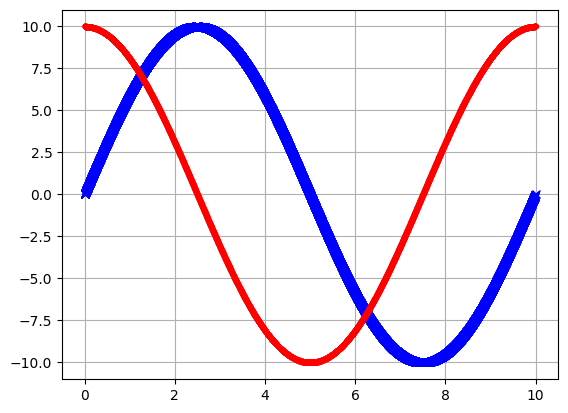

In [ ]:
s_3=10*np.sin(manipualte*frecuencia*vTiempo)
phi=np.pi/2
s_4=10*np.sin(manipualte*frecuencia*vTiempo+phi)
plt.plot(vTiempo,s_3,"xb")
plt.plot(vTiempo,s_4,".r")
plt.grid(True)
plt.show()

## Sección 3: Análisis de Autocorrelación y Correlación Cruzada

#### 1. Definición Teórica de la Autocorrelación

La **función de autocorrelación** mide el grado de similitud o dependencia lineal entre una señal $x_t$ y una versión desplazada en el tiempo de sí misma $x_{t+\tau}$, en función del retardo temporal (*lag*) $\tau$.

* **Autocovarianza Muestral no Normalizada ($C_{xx}(\tau)$):**
  $$C_{xx}(\tau) = \sum_{t=1}^{N-\tau} (x_t - \bar{x})(x_{t+\tau} - \bar{x})$$

* **Coeficiente de Autocorrelación Normalizado ($r_{xx}(\tau)$):**
  $$r_{xx}(\tau) = \frac{\sum_{t=1}^{N-\tau} (x_t - \bar{x})(x_{t+\tau} - \bar{x})}{\sum_{t=1}^{N} (x_t - \bar{x})^2}, \quad \text{donde } r_{xx}(\tau) \in [-1, 1]$$

**Variables:**
* $N$: Número total de muestras observadas.
* $\tau$: Retardo temporal (*lag*).
* $\bar{x}$: Media muestral de la señal.

---

#### 2. Casos de Estudio

##### A. Autocorrelación de una Señal Sinusoidal
Dada la señal determinista $s_1(t) = A \sin\left(2\pi f_0 t + \frac{\pi}{2}\right) = A \cos(2\pi f_0 t)$ con frecuencia $f_0 = 2 \text{ Hz}$:
* La autocorrelación de una señal periódica es también una función periódica de la misma frecuencia.
* Alcanza picos máximos de coincidencia ($r_{xx} = 1$) en retardos múltiplos enteros del período $T_0 = \frac{1}{f_0}$.

##### B. Autocorrelación de Ruido Blanco Gaussiano
Dado un proceso estocástico no correlacionado $X \sim \mathcal{N}(0, \sigma^2)$:
* **Comportamiento Teórico:**
  $$r_{xx}(\tau) = \begin{cases} 1, & \text{si } \tau = 0 \\ 0, & \text{si } \tau \neq 0 \end{cases}$$
* **Comportamiento Muestral:** Muestra un impulso en $\tau = 0$ y fluctuaciones aleatorias en torno a cero para $\tau > 0$, reflejando la independencia estocástica entre muestras.

##### C. Correlación Cruzada entre Seno y Coseno (`corr(sen, cos)`)
Para dos señales armónicas en cuadratura $x(t) = \sin(\omega t)$ e $y(t) = \cos(\omega t)$:
* Su producto interno integrado sobre un número entero de períodos es cero:
  $$\operatorname{Cov}(\sin(\omega t), \cos(\omega t)) = \frac{1}{T}\int_0^T \sin(\omega t) \cos(\omega t) \, dt = 0$$
* El seno y el coseno son **funciones ortogonales**, por lo que su coeficiente de correlación de Pearson es $r(\sin, \cos) = 0$.


In [45]:
#@title Autocorrelaciones para las diferentes señales
# Estilo
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def autocorrelacion_normalizada(x: np.ndarray, max_lag: int) -> np.ndarray:
    """Calcula el coeficiente de autocorrelacion muestral para retardos tau in [0, max_lag]."""
    x_media = x - np.mean(x)
    varianza = np.sum(x_media**2)

    r_xx = np.zeros(max_lag + 1)
    r_xx[0] = 1.0
    for tau in range(1, max_lag + 1):
        r_xx[tau] = np.dot(x_media[:-tau], x_media[tau:]) / varianza
    return r_xx

fs = 500         # Frecuencia de muestreo (Hz)
duracion = 20.0   # Duración en segundos
t = np.linspace(0, duracion, int(fs * duracion), endpoint=False)
max_tau = 100    # Retardo máximo evaluado (lags)

# Para señal sinusoidal
A = 1.0
f0 = 2.0  # Frecuencia de 2 Hz
s1 = A * np.sin(2 * np.pi * f0 * t + np.pi / 2)
r_s1 = autocorrelacion_normalizada(s1, max_lag=max_tau)

# Para ruido blanco
rng = np.random.default_rng(seed=1956)
ruido_gaussiano = rng.normal(loc=0.0, scale=1.0, size=len(t))
r_ruido = autocorrelacion_normalizada(ruido_gaussiano, max_lag=max_tau)

#Correlacion entre sen y cos
seno = np.sin(2 * np.pi * f0 * t)
coseno = np.cos(2 * np.pi * f0 * t)
r_sen_cos = np.corrcoef(seno, coseno)[0, 1]

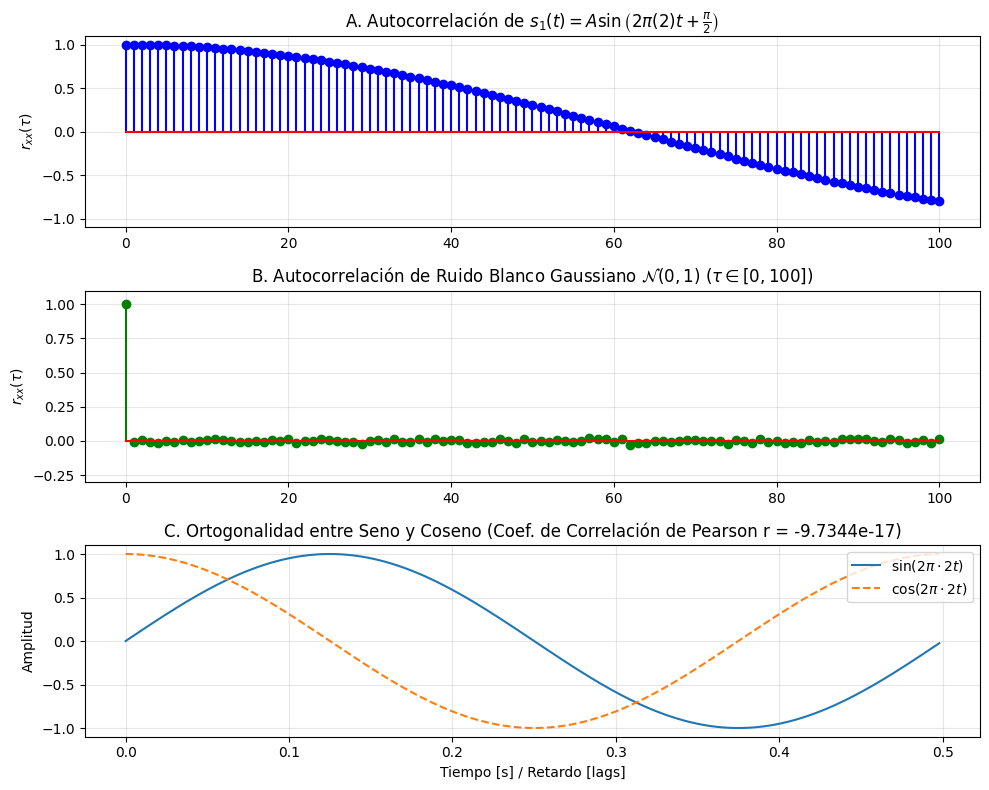

In [46]:
#@title Visualización de la Autocorrelación
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
lags = np.arange(max_tau + 1)

# Gráfico A: Autocorrelación de la Senoide
axes[0].stem(lags, r_s1, linefmt='b-', markerfmt='bo', basefmt='r-')
axes[0].set_title(r'A. Autocorrelación de $s_1(t) = A \sin\left(2\pi (2) t + \frac{\pi}{2}\right)$')
axes[0].set_ylabel(r'$r_{xx}(\tau)$')
axes[0].set_ylim(-1.1, 1.1)

# Gráfico B: Autocorrelación del Ruido Gaussiano
axes[1].stem(lags, r_ruido, linefmt='g-', markerfmt='go', basefmt='r-')
axes[1].set_title(r'B. Autocorrelación de Ruido Blanco Gaussiano $\mathcal{N}(0, 1)$ ($\tau \in [0, 100]$)')
axes[1].set_ylabel(r'$r_{xx}(\tau)$')
axes[1].set_ylim(-0.3, 1.1)

# Gráfico C: Ortogonalidad Seno vs Coseno
axes[2].plot(t[:250], seno[:250], label=r'$\sin(2\pi \cdot 2 t)$', color='tab:blue')
axes[2].plot(t[:250], coseno[:250], label=r'$\cos(2\pi \cdot 2 t)$', color='tab:orange', linestyle='--')
axes[2].set_title(f'C. Ortogonalidad entre Seno y Coseno (Coef. de Correlación de Pearson r = {r_sen_cos:.4e})')
axes[2].set_xlabel('Tiempo [s] / Retardo [lags]')
axes[2].set_ylabel('Amplitud')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()